In [16]:
from dataclasses import dataclass
from typing import Dict, List

import lightning.pytorch as pl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.models.rnn import RecurrentNetwork
from pytorch_forecasting.metrics import MAE
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Cell 1: Config + auto schema mapping (LSTM on all weather data)
@dataclass
class RunCFG:
    data_path: str = "data/raw/ember_data/all_country_data_cleaned_merged.csv"
    max_encoder_length: int = 24
    max_prediction_length: int = 6
    batch_size: int = 128
    max_epochs: int = 30
    learning_rate: float = 1e-3
    hidden_size: int = 32
    rnn_layers: int = 2
    dropout: float = 0.1
    num_workers: int = 0
    train_ratio: float = 0.8
    val_ratio: float = 0.1

cfg = RunCFG()


def detect_col(columns: List[str], candidates: List[str], required: bool = True):
    lowered = {c.lower().strip(): c for c in columns}
    for cand in candidates:
        key = cand.lower().strip()
        if key in lowered:
            return lowered[key]
    if required:
        raise ValueError(f"Khong tim thay cot trong cac lua chon: {candidates}")
    return None


def infer_schema(columns: List[str]) -> Dict[str, List[str]]:
    time_col = detect_col(columns, ["date", "datetime", "time", "timestamp"])
    target_col = detect_col(columns, ["generation_twh", "generation", "target", "load"])

    entity_col = detect_col(columns, ["entity", "country", "nation"], required=False)
    series_col = detect_col(columns, ["series", "fuel", "source"], required=False)
    is_agg_col = detect_col(columns, ["is_aggregate_series", "is_aggregate"], required=False)

    group_ids = []
    if entity_col: group_ids.append(entity_col)
    if series_col: group_ids.append(series_col)
    if not group_ids: group_ids = ["series_id"]

    static_categoricals = [c for c in [entity_col, series_col, is_agg_col] if c is not None]

    excluded = {
        time_col,
        target_col,
        "gas_vol",
        "castlecoal_vol",
        "series_id",
        "entity code"
    }
    excluded.update(group_ids)
    excluded.update(static_categoricals)

    known_reals = ["time_idx", "year", "month", "month_sin", "month_cos"]
    weather_vars = [c for c in columns if c.lower() not in excluded and c not in excluded]
    # FIX: RecurrentNetwork (LSTM) in pytorch_forecasting requires all inputs to be available in both decoder/encoder
    known_reals.extend(weather_vars)
    unknown_reals = [target_col]

    return {
        "time_col": time_col,
        "target_col": target_col,
        "group_ids": group_ids,
        "static_categoricals": static_categoricals,
        "static_reals": [],
        "time_varying_known_categoricals": [],
        "time_varying_known_reals": known_reals,
        "time_varying_unknown_categoricals": [],
        "time_varying_unknown_reals": unknown_reals,
    }


print("Config ready for global merged dataset with weathering data. Chay Cell 2.")

Config ready for global merged dataset with weathering data. Chay Cell 2.


In [17]:
# Cell 2: Load data + feature engineering + split
df_raw = pd.read_csv(cfg.data_path)

if "series_id" not in df_raw.columns and "series" not in df_raw.columns:
    df_raw["series_id"] = "GLOBAL_SERIES"

schema = infer_schema(df_raw.columns.tolist())

print("Schema auto-detected:")
for k, v in schema.items():
    print(f"- {k}: {v}")

def to_float_series(s: pd.Series) -> pd.Series:
    txt = s.astype(str).str.strip().replace({"": np.nan, "nan": np.nan, "None": np.nan})
    suffix = txt.str.extract(r"([KMB])$", expand=False)
    base = pd.to_numeric(txt.str.replace(r"[KMB]$", "", regex=True), errors="coerce")

    mult = pd.Series(1.0, index=s.index, dtype="float32")
    mult[suffix == "K"] = 1e3
    mult[suffix == "M"] = 1e6
    mult[suffix == "B"] = 1e9
    return (base * mult).astype("float32")


def prepare_dataframe(df: pd.DataFrame, schema: Dict[str, List[str]], cfg: RunCFG) -> pd.DataFrame:
    time_col = schema["time_col"]
    target_col = schema["target_col"]
    group_ids = schema["group_ids"]

    required_cols = set(group_ids + [time_col, target_col])
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Thieu cot bat buoc: {missing}")

    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce", dayfirst=True)
    df = df.dropna(subset=[time_col]).reset_index(drop=True)

    cat_cols = list(set(schema["group_ids"] + schema["static_categoricals"]))
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).replace({"nan": "UNK", "None": "UNK"})

    if "series" in df.columns:
        before_rows = len(df)
        df = df[~df["series"].str.lower().str.contains("total", na=False)].copy()
        if before_rows - len(df) > 0:
            print(f"Removed total-series rows: {before_rows - len(df):,}")

    # FIX: Parse tat ca cac numeric variable bao gom ca known_reals (ngoai tru thoi gian)
    dyn_cols = [c for c in schema["time_varying_unknown_reals"] + schema["time_varying_known_reals"]
                if c in df.columns and c not in ["time_idx", "year", "month", "month_sin", "month_cos"]]

    for col in dyn_cols:
        if df[col].dtype == object or df[col].dtype == str:
            df[col] = to_float_series(df[col])

    df = df.dropna(subset=[target_col])

    feature_num_cols = [c for c in dyn_cols if c != target_col]
    for col in feature_num_cols:
        group_median = df.groupby(group_ids)[col].transform("median")
        global_median = float(df[col].median()) if df[col].notna().any() else 0.0
        df[col] = df[col].fillna(group_median).fillna(global_median).astype("float32")

    df["year"] = df[time_col].dt.year.astype("int16")
    df["month"] = df[time_col].dt.month.astype("int8")
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12).astype("float32")
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12).astype("float32")

    unique_dates = np.sort(df[time_col].dropna().unique())
    date_to_idx = {d: i for i, d in enumerate(unique_dates)}
    df["time_idx"] = df[time_col].map(date_to_idx).astype("int32")

    df = df.sort_values(group_ids + [time_col]).reset_index(drop=True)

    min_required_len = cfg.max_encoder_length + cfg.max_prediction_length
    series_len = df.groupby(group_ids)["time_idx"].nunique().reset_index(name="series_len")
    valid_groups = series_len[series_len["series_len"] >= min_required_len][group_ids]

    df = df.merge(valid_groups, on=group_ids, how="inner")
    if df.empty:
        raise ValueError("Khong con chuoi hop le. Co the giam max_encoder_length hoac max_prediction_length.")

    return df


def compute_cutoffs(df: pd.DataFrame, cfg: RunCFG):
    max_time_idx = int(df["time_idx"].max())
    train_cutoff = int(max_time_idx * cfg.train_ratio)
    val_cutoff = int(max_time_idx * (cfg.train_ratio + cfg.val_ratio))
    return train_cutoff, val_cutoff


df = prepare_dataframe(df_raw, schema, cfg)
train_cutoff, val_cutoff = compute_cutoffs(df, cfg)

print(f"Global time_idx max: {df['time_idx'].max()}")
print(f"Cutoff -> train: {train_cutoff} | val: {val_cutoff}")
print(f"Rows total: {len(df):,} | Groups: {df[schema['group_ids']].drop_duplicates().shape[0]:,}")

Schema auto-detected:
- time_col: date
- target_col: generation_TWh
- group_ids: ['entity', 'series']
- static_categoricals: ['entity', 'series']
- static_reals: []
- time_varying_known_categoricals: []
- time_varying_known_reals: ['time_idx', 'year', 'month', 'month_sin', 'month_cos', 'precipitation', 'solar', 'humidity', 'temperature']
- time_varying_unknown_categoricals: []
- time_varying_unknown_reals: ['generation_TWh']
Removed total-series rows: 1,239
Global time_idx max: 95
Cutoff -> train: 76 | val: 85
Rows total: 9,274 | Groups: 105


In [18]:
# Cell 3: Build TimeSeriesDataSet + DataLoader
def build_datasets(df, train_cutoff, val_cutoff, schema: Dict[str, List[str]], cfg: RunCFG):
    train_df = df[df["time_idx"] <= train_cutoff].copy()
    val_df = df[df["time_idx"] <= val_cutoff].copy()
    test_df = df.copy()

    training = TimeSeriesDataSet(
        train_df,
        time_idx="time_idx",
        target=schema["target_col"],
        group_ids=schema["group_ids"],
        min_encoder_length=cfg.max_encoder_length // 2,
        max_encoder_length=cfg.max_encoder_length,
        min_prediction_length=1,
        max_prediction_length=cfg.max_prediction_length,
        static_categoricals=schema["static_categoricals"],
        static_reals=schema["static_reals"],
        time_varying_known_categoricals=schema["time_varying_known_categoricals"],
        time_varying_known_reals=schema["time_varying_known_reals"],
        time_varying_unknown_categoricals=schema["time_varying_unknown_categoricals"],
        time_varying_unknown_reals=schema["time_varying_unknown_reals"],
        target_normalizer=GroupNormalizer(groups=schema["group_ids"], transformation="softplus"),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        allow_missing_timesteps=True, # FIX: Xu ly loi missing month data
    )

    validation = TimeSeriesDataSet.from_dataset(
        training,
        val_df,
        min_prediction_idx=train_cutoff + 1,
        stop_randomization=True,
    )
    testing = TimeSeriesDataSet.from_dataset(
        training,
        test_df,
        min_prediction_idx=val_cutoff + 1,
        stop_randomization=True,
    )

    train_loader = training.to_dataloader(train=True, batch_size=cfg.batch_size, num_workers=cfg.num_workers)
    val_loader = validation.to_dataloader(train=False, batch_size=cfg.batch_size, num_workers=cfg.num_workers)
    test_loader = testing.to_dataloader(train=False, batch_size=cfg.batch_size, num_workers=cfg.num_workers)

    return training, train_loader, val_loader, test_loader


training, train_loader, val_loader, test_loader = build_datasets(df, train_cutoff, val_cutoff, schema, cfg)
print("Dataloader ready.")

Dataloader ready.


In [19]:
# Cell 4: Create model + trainer
pl.seed_everything(42)

early_stop_cb = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=8, mode="min")
lr_logger = LearningRateMonitor()
ckpt_cb = ModelCheckpoint(
    dirpath="checkpoint_lstm",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="lstm-pretrain-best-{epoch:02d}-{val_loss:.4f}",
)

trainer = pl.Trainer(
    max_epochs=cfg.max_epochs,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop_cb, lr_logger, ckpt_cb],
    log_every_n_steps=20,
)

# Khởi tạo mô hình mạng LSTM
model = RecurrentNetwork.from_dataset(
    training,
    cell_type="LSTM",
    hidden_size=cfg.hidden_size,
    rnn_layers=cfg.rnn_layers,
    dropout=cfg.dropout,
    learning_rate=cfg.learning_rate,
    loss=MAE(),
    reduce_on_plateau_patience=4,
)

print("LSTM Model + trainer ready.")

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LSTM Model + trainer ready.


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [20]:
# Cell 5: Train
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
best_ckpt = ckpt_cb.best_model_path
print(f"Best checkpoint saved at: {best_ckpt}")

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss             │ MAE            │      0 │ train │     0 │
│ 1 │ logging_metrics  │ ModuleList     │      0 │ train │     0 │
│ 2 │ embeddings       │ MultiEmbedding │    143 │ train │     0 │
│ 3 │ rnn              │ LSTM           │ 16.1 K │ train │     0 │
│ 4 │ output_projector │ Linear         │     33 │ train │     0 │
└───┴──────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 16.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 16.3 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\utilities\_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\trainer\connectors\data_
connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\trainer\connectors\data_
connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

Best checkpoint saved at: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint_lstm\lstm-pretrain-best-epoch=12-val_loss=0.3943.ckpt


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi

Su dung best_ckpt: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint_lstm\lstm-pretrain-best-epoch=12-val_loss=0.3943.ckpt


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


MAE : 0.9589
RMSE: 4.9724
R^2 : 0.7941


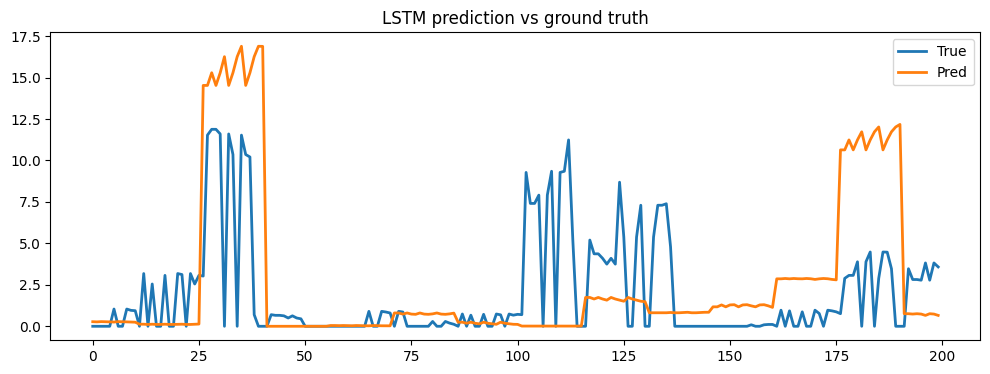

'checkpoint\\lstm_model.ckpt'

In [23]:
# Cell 6: Evaluate quick metrics + plot
import os
import glob
import shutil
from sklearn.metrics import r2_score

if 'best_ckpt' not in locals() or not best_ckpt:
    list_of_files = glob.glob('checkpoint/*.ckpt')
    if not list_of_files:
        raise FileNotFoundError("Khong tim thay checkpoint nao. Vui long chay qua Cell 5.")
    best_ckpt = max(list_of_files, key=os.path.getctime)
    print(f"Lay duoc checkpoint tu dong: {best_ckpt}")
else:
    print(f"Su dung best_ckpt: {best_ckpt}")

best_model = RecurrentNetwork.load_from_checkpoint(best_ckpt)
preds = best_model.predict(test_loader, mode="prediction")

y_true = []
for _, batch_y in test_loader:
    target = batch_y[0] if isinstance(batch_y, tuple) else batch_y
    y_true.append(target.detach().cpu().numpy())

y_true = np.concatenate([arr.flatten() for arr in y_true], axis=0)
y_pred = preds.detach().cpu().numpy().reshape(-1)

n = min(len(y_true), len(y_pred))
y_true = y_true[:n]
y_pred = y_pred[:n]

mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2 : {r2:.4f}")

plt.figure(figsize=(12, 4))
plt.plot(y_true[-200:], label="True", linewidth=2)
plt.plot(y_pred[-200:], label="Pred", linewidth=2)
plt.title("LSTM prediction vs ground truth")
plt.legend()
plt.show()

# --- Luu mang transfer learning ---
target_dir = "checkpoint"
os.makedirs(target_dir, exist_ok=True)
dest_path = os.path.join(target_dir, "lstm_model.ckpt")
shutil.copy(best_ckpt, dest_path)

